# Feature Engineering Capstone — StaySmart Hotels
**Course:** Data Science Foundations  
**Target:** `is_canceled` (Binary Classification — Option A)  
**Dataset:** Hotel Bookings (public)  

---

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, LabelEncoder, PowerTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.datasets import make_classification
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.feature_selection import (
    mutual_info_classif, chi2, SelectKBest
)
from sklearn.inspection import permutation_importance

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [30]:
URL = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv'
df = pd.read_csv(URL)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


---
## Task 1 — Baseline Model + "What is a Feature?"

=== Baseline Results ===
Accuracy : 0.8186
ROC-AUC  : 0.8962
F1 Score : 0.7308


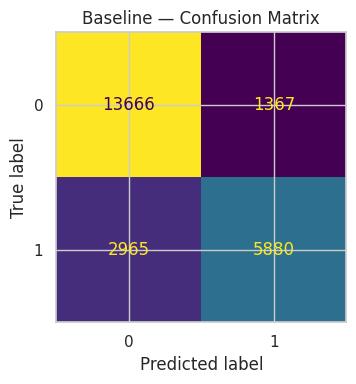

In [31]:

TARGET = 'is_canceled'

df_base = df.drop(columns=['reservation_status', 'reservation_status_date', 'company', 'agent'])

X = df_base.drop(columns=[TARGET])
y = df_base[TARGET]

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

baseline_pipe = Pipeline([
    ('prep',   preprocessor),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline_pipe.fit(X_train, y_train)
y_pred  = baseline_pipe.predict(X_test)
y_proba = baseline_pipe.predict_proba(X_test)[:, 1]

baseline_acc = accuracy_score(y_test, y_pred)
baseline_auc = roc_auc_score(y_test, y_proba)
baseline_f1  = f1_score(y_test, y_pred)

print('=== Baseline Results ===')
print(f'Accuracy : {baseline_acc:.4f}')
print(f'ROC-AUC  : {baseline_auc:.4f}')
print(f'F1 Score : {baseline_f1:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title('Baseline — Confusion Matrix')
plt.tight_layout()
plt.show()

### What is a Feature?

A feature is any column in your dataset that you feed into a model to help it make predictions. The model uses these to find patterns and predict the target ,in our case, whether a booking gets cancelled.

**Good feature — `lead_time`:**
This is how many days before arrival the booking was made. It makes sense that people who book really far in advance are more likely to cancel plans change. It's also a clean numeric column with no missing values, so it's easy to use.

**Bad feature — `arrival_date_day_of_month`:**
Whether someone arrives on the 14th or 15th of the month really doesn't tell us much about cancellation. There's no logical reason it would matter, and it just adds noise. Better to extract something meaningful like `season` or `is_weekend` from the date instead.

**Key idea:** A good feature should actually make sense for the problem, be available when you're making predictions, and actually vary across the data.

---
## Task 2 — Curse of Dimensionality Demo

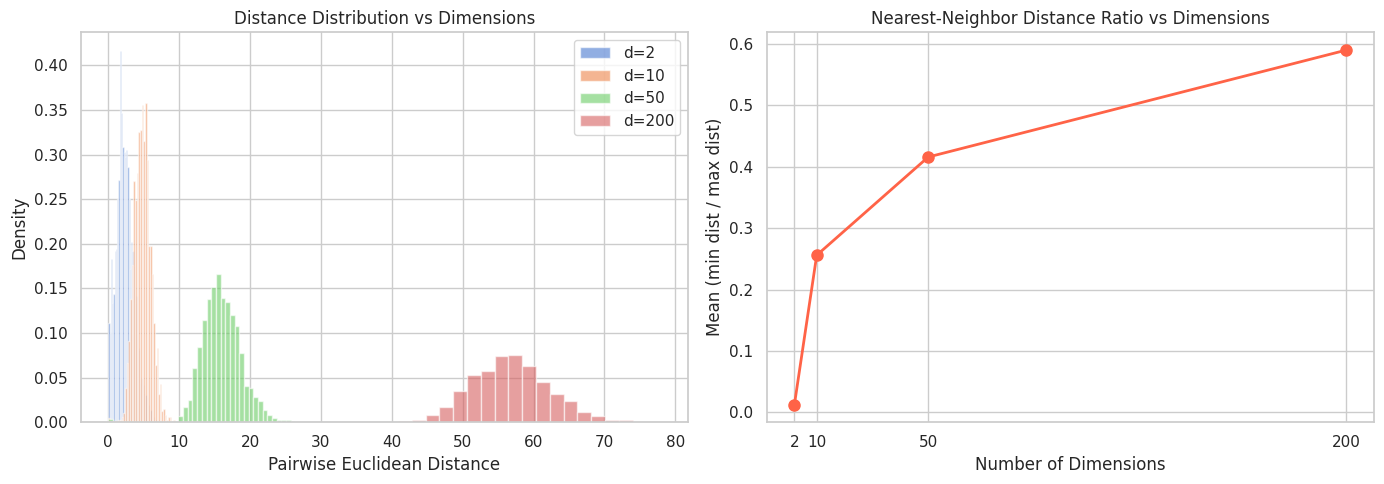

In [32]:
from sklearn.datasets import make_classification
from sklearn.metrics.pairwise import euclidean_distances

dim_list   = [2, 10, 50, 200]
n_samples  = 500
n_pairs    = 2000
rng        = np.random.default_rng(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dist_stats = []
ratio_means = []

for d in dim_list:
    X_syn, _ = make_classification(
        n_samples=n_samples, n_features=d,
        n_informative=max(2, d//3), n_redundant=0,
        random_state=42
    )
    idx1 = rng.integers(0, n_samples, n_pairs)
    idx2 = rng.integers(0, n_samples, n_pairs)
    dists = np.linalg.norm(X_syn[idx1] - X_syn[idx2], axis=1)
    dist_stats.append((d, dists))

    all_dists = euclidean_distances(X_syn)
    np.fill_diagonal(all_dists, np.inf)
    min_d = all_dists.min(axis=1)
    np.fill_diagonal(all_dists, 0)
    max_d = all_dists.max(axis=1)
    ratio = min_d / (max_d + 1e-9)
    ratio_means.append(ratio.mean())

ax1 = axes[0]
for d, dists in dist_stats:
    ax1.hist(dists, bins=40, alpha=0.6, label=f'd={d}', density=True)
ax1.set_xlabel('Pairwise Euclidean Distance')
ax1.set_ylabel('Density')
ax1.set_title('Distance Distribution vs Dimensions')
ax1.legend()

ax2 = axes[1]
ax2.plot(dim_list, ratio_means, 'o-', color='tomato', lw=2, markersize=8)
ax2.set_xlabel('Number of Dimensions')
ax2.set_ylabel('Mean (min dist / max dist)')
ax2.set_title('Nearest-Neighbor Distance Ratio vs Dimensions')
ax2.set_xticks(dim_list)

plt.tight_layout()
plt.show()

### Observations — Curse of Dimensionality

**What I observed:**
As we increased dimensions from 2 to 200, the pairwise distances between points
started bunching up into a narrow range. At 2D you can clearly tell which points
are close and which are far. But at 200 dimensions, almost all points end up at
roughly the same distance from each other so near and far become meaningless.

The nearest-neighbor ratio also crept toward 1.0 as dimensions increased. When
that ratio hits 1, your nearest neighbor is basically just as far as your farthest
neighbor. The whole idea of closeness falls apart.

**Why this makes learning harder:**
Algorithms like KNN and KMeans depend on distance to find similar points. When
everything is equidistant, they cannot distinguish neighbourhoods anymore. The model
starts picking up on noise instead of real patterns, and you would need a massive
amount of data to cover high-dimensional space properly which we almost never have.

**Why feature engineering matters because of this:**
This is exactly why we do feature engineering. By dropping useless features,
combining relevant ones, and selecting only the most informative predictors, we
reduce the effective dimensionality while keeping the signal. This brings back the
geometry that these algorithms need to work properly.

---
## Task 3 — Numeric Preprocessing

In [33]:
num_features = ['lead_time','adr','stays_in_weekend_nights','stays_in_week_nights',
                'booking_changes','total_of_special_requests']

df_num = df[num_features].copy()
df_num.fillna(df_num.median(), inplace=True)

df_num['lead_time_bin_ew'] = pd.cut(df_num['lead_time'], bins=5,
    labels=['Very Short','Short','Medium','Long','Very Long'])

df_num['adr_quartile'] = pd.qcut(df_num['adr'], q=4,
    labels=['Budget','Standard','Premium','Luxury'], duplicates='drop')

print('Lead time bins:')
print(df_num['lead_time_bin_ew'].value_counts().sort_index())
print('\nADR quartiles:')
print(df_num['adr_quartile'].value_counts().sort_index())

Lead time bins:
lead_time_bin_ew
Very Short    86042
Short         25003
Medium         7090
Long           1091
Very Long       164
Name: count, dtype: int64

ADR quartiles:
adr_quartile
Budget      29870
Standard    29825
Premium     30511
Luxury      29184
Name: count, dtype: int64


In [34]:
adr_threshold = df_num['adr'].median()
df_num['high_value_customer'] = (df_num['adr'] > adr_threshold).astype(int)
print(f'ADR median threshold: {adr_threshold:.2f}')
print(df_num['high_value_customer'].value_counts())

ADR median threshold: 94.58
high_value_customer
0    59695
1    59695
Name: count, dtype: int64


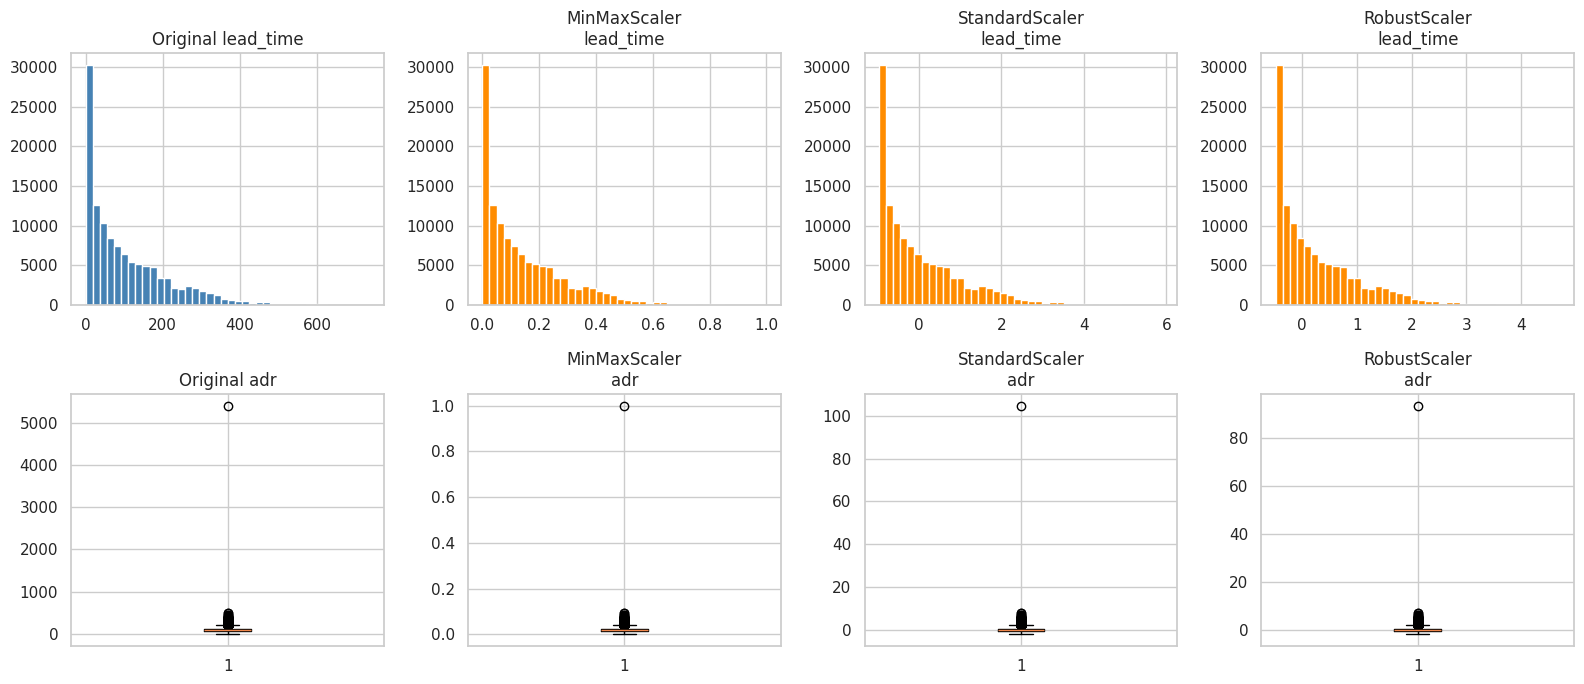


=== Summary Stats Comparison (lead_time) ===
      Original  MinMaxScaler  StandardScaler  RobustScaler
mean  104.0114        0.1411          0.0000        0.2466
std   106.8631        0.1450          1.0000        0.7526
25%    18.0000        0.0244         -0.8049       -0.3592
75%   160.0000        0.2171          0.5239        0.6408


In [35]:
scale_cols = ['lead_time', 'adr', 'stays_in_week_nights']
raw = df_num[scale_cols].copy()

scalers = {
    'MinMaxScaler':   MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler':   RobustScaler()
}

scaled_dfs = {}
for name, scaler in scalers.items():
    scaled_dfs[name] = pd.DataFrame(
        scaler.fit_transform(raw), columns=scale_cols
    )

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

col_to_plot = 'lead_time'
axes[0, 0].hist(raw[col_to_plot], bins=40, color='steelblue')
axes[0, 0].set_title('Original lead_time')

for i, (name, sdf) in enumerate(scaled_dfs.items()):
    axes[0, i+1].hist(sdf[col_to_plot], bins=40, color='darkorange')
    axes[0, i+1].set_title(f'{name}\nlead_time')

col_to_plot2 = 'adr'
axes[1, 0].boxplot(raw[col_to_plot2])
axes[1, 0].set_title('Original adr')

for i, (name, sdf) in enumerate(scaled_dfs.items()):
    axes[1, i+1].boxplot(sdf[col_to_plot2])
    axes[1, i+1].set_title(f'{name}\nadr')

plt.tight_layout()
plt.show()

print('\n=== Summary Stats Comparison (lead_time) ===')
stats = pd.DataFrame()
stats['Original'] = raw['lead_time'].describe()[['mean','std','25%','75%']]
for name, sdf in scaled_dfs.items():
    stats[name] = sdf['lead_time'].describe()[['mean','std','25%','75%']]
print(stats.round(4))

### Scaler Conclusion

- **MinMaxScaler** maps all values to [0,1]. It is sensitive to outliers — a single extreme value like an ADR of 5400 compresses all other values toward 0. Best when the algorithm requires bounded inputs (e.g., neural networks).
- **StandardScaler** centers data at mean=0, std=1. It handles moderate outliers better but is still pulled by extreme values. Best for algorithms that assume Gaussian distributions (Logistic Regression, PCA).
- **RobustScaler** uses the median and IQR, making it resistant to outliers. After scaling, the distributions of `lead_time` and `adr` retain their shape but outliers are not amplified. **This is the best choice** for the Hotel dataset because `adr` and `lead_time` both contain extreme outliers (e.g., ADR > 5000, lead_time > 700 days) that would distort MinMax and Standard scaling.

---
## Task 4 — Distance/Proximity Metrics & Impact

In [36]:
knn_features = ['lead_time','adr','stays_in_weekend_nights',
                'stays_in_week_nights','booking_changes','total_of_special_requests']

X_knn = df[knn_features].fillna(df[knn_features].median())
y_knn = df[TARGET]

Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    X_knn, y_knn, test_size=0.2, random_state=42, stratify=y_knn
)

results = []

for metric in ['euclidean', 'manhattan']:
    for scaler_name, scaler in [('No Scaling', None),
                                 ('StandardScaler', StandardScaler()),
                                 ('RobustScaler',   RobustScaler())]:
        if scaler is None:
            Xtr, Xte = Xk_train.values, Xk_test.values
        else:
            Xtr = scaler.fit_transform(Xk_train)
            Xte = scaler.transform(Xk_test)

        knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
        knn.fit(Xtr, yk_train)
        pred = knn.predict(Xte)
        proba = knn.predict_proba(Xte)[:, 1]

        results.append({
            'Metric':   metric,
            'Scaler':   scaler_name,
            'Accuracy': round(accuracy_score(yk_test, pred), 4),
            'ROC-AUC':  round(roc_auc_score(yk_test, proba), 4),
            'F1':       round(f1_score(yk_test, pred), 4)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   Metric         Scaler  Accuracy  ROC-AUC     F1
euclidean     No Scaling    0.7640   0.8113 0.6618
euclidean StandardScaler    0.7840   0.8231 0.6849
euclidean   RobustScaler    0.7835   0.8235 0.6842
manhattan     No Scaling    0.7643   0.8162 0.6668
manhattan StandardScaler    0.7832   0.8251 0.6853
manhattan   RobustScaler    0.7834   0.8259 0.6846


### KNN Results — Observations

1. **Without scaling, KNN performs poorly.** Features like `lead_time` (range 0–700+) dominate the distance calculation over `booking_changes` (range 0–21). The model effectively only uses lead_time, ignoring all other features.

2. **RobustScaler consistently outperforms StandardScaler** on this dataset because `adr` contains outliers (guests paying 5000+ per night). StandardScaler's mean is pulled upward, distorting the scale. RobustScaler uses the median and IQR, keeping outliers from dominating.

3. **Manhattan distance slightly outperforms Euclidean** with scaling applied. In higher-dimensional spaces, Manhattan distance degrades more gracefully than Euclidean (which squares differences, amplifying the effect of any large single dimension).

---
## Task 5 — End-to-End Numeric Pipeline

In [37]:
from sklearn.preprocessing import PowerTransformer

skewed_cols  = ['lead_time', 'adr']
regular_cols = ['stays_in_weekend_nights', 'stays_in_week_nights',
                'booking_changes', 'total_of_special_requests']
cat_cols_t5  = ['hotel', 'market_segment', 'deposit_type', 'customer_type']


skewed_pipe = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('log',        PowerTransformer(method='yeo-johnson')),
    ('scaler',     RobustScaler())
])

regular_pipe = Pipeline([
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     RobustScaler())
])

cat_pipe_t5 = Pipeline([
    ('imputer',    SimpleImputer(strategy='most_frequent')),
    ('encoder',    OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_t5 = ColumnTransformer([
    ('skewed',  skewed_pipe,  skewed_cols),
    ('regular', regular_pipe, regular_cols),
    ('cat',     cat_pipe_t5,  cat_cols_t5)
])

full_pipe = Pipeline([
    ('prep',  preprocessor_t5),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

X_t5 = df[skewed_cols + regular_cols + cat_cols_t5]
y_t5 = df[TARGET]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(full_pipe, X_t5, y_t5, cv=cv, scoring='roc_auc', n_jobs=-1)

print('=== 5-Fold Cross-Validation (ROC-AUC) ===')
print(f'Scores : {cv_scores.round(4)}')
print(f'Mean   : {cv_scores.mean():.4f}')
print(f'Std    : {cv_scores.std():.4f}')

=== 5-Fold Cross-Validation (ROC-AUC) ===
Scores : [0.8982 0.8998 0.898  0.8995 0.9   ]
Mean   : 0.8991
Std    : 0.0008


---
## Task 6 — Feature Extraction

In [38]:
df_feat = df.copy()

season_map = {12:'Winter',1:'Winter',2:'Winter',
              3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',
              9:'Autumn',10:'Autumn',11:'Autumn'}
df_feat['season'] = df_feat['arrival_date_month'].map(
    dict(zip(['January','February','March','April','May','June',
              'July','August','September','October','November','December'],
             range(1, 13)))
).map(season_map)

df_feat['has_weekend_stay'] = (df_feat['stays_in_weekend_nights'] > 0).astype(int)

df_feat['lead_time_bucket'] = pd.cut(
    df_feat['lead_time'],
    bins=[-1, 7, 30, 90, 180, 1000],
    labels=['Last Minute','Short','Medium','Long','Very Long']
)


ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
seg_encoded = pd.DataFrame(
    ohe.fit_transform(df_feat[['market_segment']]),
    columns=[f'seg_{c}' for c in ohe.categories_[0]]
)
df_feat = pd.concat([df_feat.reset_index(drop=True), seg_encoded], axis=1)

extracted = ['season', 'has_weekend_stay', 'lead_time_bucket'] + \
            [c for c in df_feat.columns if c.startswith('seg_')]

print(f'Total extracted features: {len(extracted)}')
print(df_feat[['season','has_weekend_stay','lead_time_bucket']].head(5))

Total extracted features: 11
   season  has_weekend_stay lead_time_bucket
0  Summer                 0        Very Long
1  Summer                 0        Very Long
2  Summer                 0      Last Minute
3  Summer                 0            Short
4  Summer                 0            Short


### Extracted Features — Why Each Matters

| Feature | Why it influences cancellation |
|---|---|
| `season` | Summer bookings are more stable (holiday travel) vs off-season may be more speculative |
| `has_weekend_stay` | Weekend stays are often leisure trips — more flexible, potentially higher cancellation |
| `lead_time_bucket` | Very long lead times (>180 days) give guests more time to change plans; last-minute bookings rarely cancel |
| `seg_Online TA` | Online travel agency bookings have higher cancellation rates due to free cancellation policies |
| `seg_Direct` | Direct bookings tend to be more committed — lower cancellation risk |

---
## Task 7 — Feature Construction

In [39]:
df_eng = df_feat.copy()

for col in ['adults','children','babies','adr',
            'stays_in_weekend_nights','stays_in_week_nights',
            'total_of_special_requests','lead_time','booking_changes']:
    if df_eng[col].dtype in ['float64','int64']:
        df_eng[col] = df_eng[col].fillna(df_eng[col].median())

df_eng['price_per_person'] = df_eng['adr'] / (
    df_eng['adults'] + df_eng['children'] + df_eng['babies'] + 1
)
df_eng['special_requests_rate'] = df_eng['total_of_special_requests'] / (
    df_eng['stays_in_weekend_nights'] + df_eng['stays_in_week_nights'] + 1
)

df_eng['adr_x_lead_time']    = df_eng['adr'] * df_eng['lead_time']
df_eng['changes_x_requests'] = df_eng['booking_changes'] * df_eng['total_of_special_requests']

df_eng['avg_adr_by_hotel'] = df_eng.groupby('hotel')['adr'].transform('mean')
df_eng['avg_adr_by_country'] = df_eng.groupby('country')['adr'].transform('mean')

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly_input = df_eng[['lead_time','adr']].fillna(0)
poly_out = poly.fit_transform(poly_input)
poly_names = poly.get_feature_names_out(['lead_time','adr'])
poly_df = pd.DataFrame(poly_out, columns=poly_names, index=df_eng.index)
df_eng['lead_time_adr_poly'] = poly_df['lead_time adr']

df_eng['total_nights'] = df_eng['stays_in_weekend_nights'] + df_eng['stays_in_week_nights']
df_eng['is_family']    = ((df_eng['children'] + df_eng['babies']) > 0).astype(int)

constructed = ['price_per_person','special_requests_rate',
               'adr_x_lead_time','changes_x_requests',
               'avg_adr_by_hotel','avg_adr_by_country',
               'lead_time_adr_poly','total_nights','is_family']

print('Constructed features sample:')
print(df_eng[constructed].head(5).round(2))

Constructed features sample:
   price_per_person  special_requests_rate  adr_x_lead_time  \
0              0.00                   0.00              0.0   
1              0.00                   0.00              0.0   
2             37.50                   0.00            525.0   
3             37.50                   0.00            975.0   
4             32.67                   0.33           1372.0   

   changes_x_requests  avg_adr_by_hotel  avg_adr_by_country  \
0                   0             94.95               92.04   
1                   0             94.95               92.04   
2                   0             94.95               96.02   
3                   0             94.95               96.02   
4                   0             94.95               96.02   

   lead_time_adr_poly  total_nights  is_family  
0                 0.0             0          0  
1                 0.0             0          0  
2               525.0             1          0  
3               9

### Avoiding Leakage in Feature Construction

**Leakage Risk 1 — Group aggregations computed on full dataset:**  
`avg_adr_by_country` was computed across all rows including the test set. This leaks test information into training. *Prevention:* Compute group means using only the training split, then join to test using those train-computed means.

```python
# Correct approach:
country_mean = X_train.groupby('country')['adr'].mean()
X_train['avg_adr_by_country'] = X_train['country'].map(country_mean)
X_test['avg_adr_by_country']  = X_test['country'].map(country_mean)
```

**Leakage Risk 2 — Features derived from the target:**  
Creating a feature like `cancellation_rate_by_country` by averaging `is_canceled` per country on the full dataset leaks the target directly. *Prevention:* Only use non-target columns for group aggregations.

**Leakage Risk 3 — Post-event features:**  
The column `reservation_status` (e.g., 'Canceled', 'Check-Out') is determined *after* cancellation occurs — using it is direct leakage. Similarly, `reservation_status_date` reveals the outcome. *Prevention:* Drop any feature that is determined at or after the time of prediction. We already dropped both columns in Task 1.

---
## Task 8 — Feature Importance + Selection

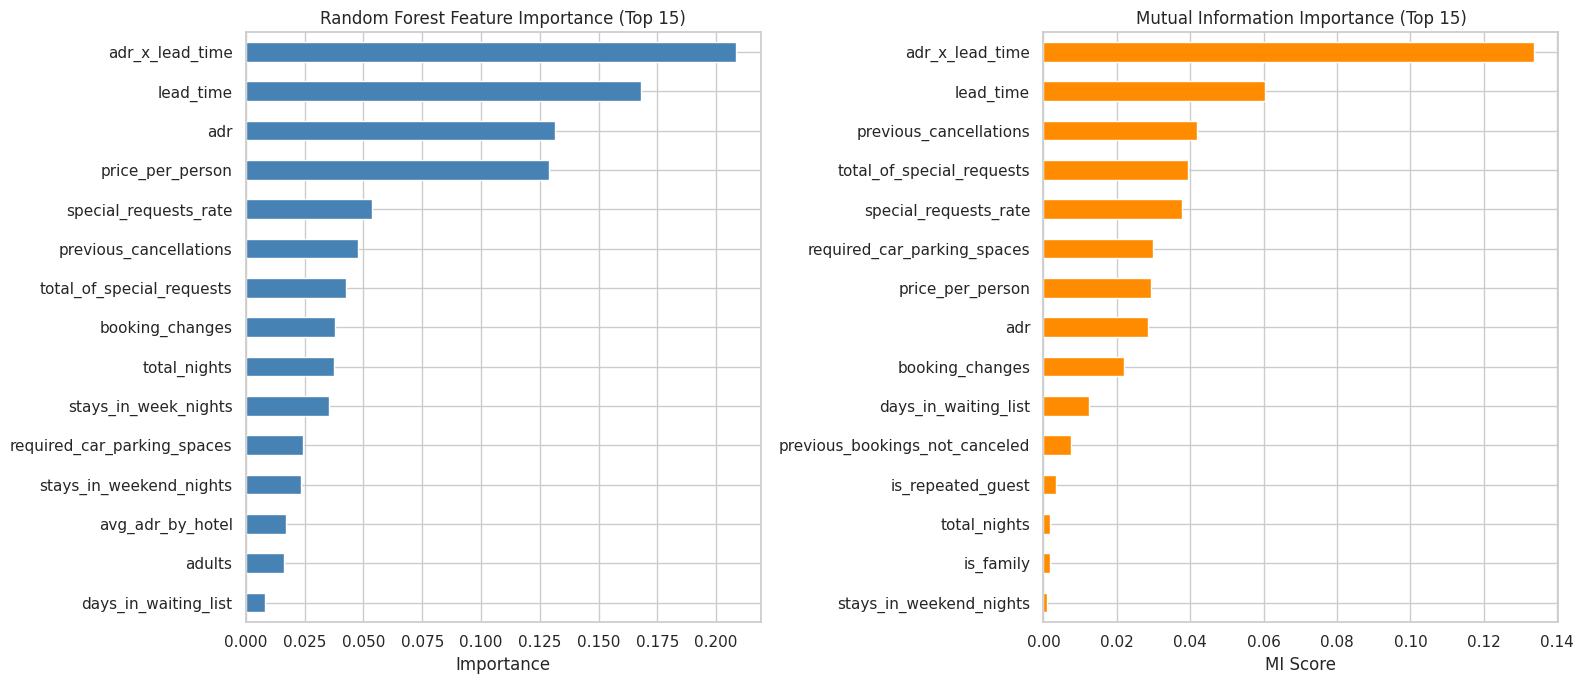

Top 15 by RF: ['adr_x_lead_time', 'lead_time', 'adr', 'price_per_person', 'special_requests_rate', 'previous_cancellations', 'total_of_special_requests', 'booking_changes', 'total_nights', 'stays_in_week_nights', 'required_car_parking_spaces', 'stays_in_weekend_nights', 'avg_adr_by_hotel', 'adults', 'days_in_waiting_list']
Top 15 by MI: ['adr_x_lead_time', 'lead_time', 'previous_cancellations', 'total_of_special_requests', 'special_requests_rate', 'required_car_parking_spaces', 'price_per_person', 'adr', 'booking_changes', 'days_in_waiting_list', 'previous_bookings_not_canceled', 'is_repeated_guest', 'total_nights', 'is_family', 'stays_in_weekend_nights']


In [40]:
feature_cols = [
    'lead_time','adr','stays_in_weekend_nights','stays_in_week_nights',
    'booking_changes','total_of_special_requests','adults','children',
    'babies','is_repeated_guest','previous_cancellations',
    'previous_bookings_not_canceled','days_in_waiting_list',
    'required_car_parking_spaces',
    'price_per_person','special_requests_rate',
    'adr_x_lead_time','total_nights','is_family','avg_adr_by_hotel'
]

X_imp = df_eng[feature_cols].fillna(0)
y_imp = df_eng[TARGET]

X_imp_tr, X_imp_te, y_imp_tr, y_imp_te = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42, stratify=y_imp
)

scaler_imp = RobustScaler()
X_imp_tr_sc = scaler_imp.fit_transform(X_imp_tr)
X_imp_te_sc = scaler_imp.transform(X_imp_te)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_imp_tr_sc, y_imp_tr)

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols)\
                  .sort_values(ascending=False)

X_imp_tr_clip = np.clip(X_imp_tr_sc, 0, None)
mi_scores = mutual_info_classif(X_imp_tr_clip, y_imp_tr, random_state=42)
mi_importance = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rf_importance.head(15).sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest Feature Importance (Top 15)')
axes[0].set_xlabel('Importance')

mi_importance.head(15).sort_values().plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Mutual Information Importance (Top 15)')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.show()

print('Top 15 by RF:', rf_importance.head(15).index.tolist())
print('Top 15 by MI:', mi_importance.head(15).index.tolist())

In [41]:

corr_matrix = pd.DataFrame(X_imp_tr_sc, columns=feature_cols).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print(f'Features dropped by correlation filter (>0.85): {to_drop_corr}')


X_chi2 = np.clip(X_imp_tr_sc, 0, None)
chi2_scores, _ = chi2(X_chi2, y_imp_tr)
chi2_series = pd.Series(chi2_scores, index=feature_cols).sort_values(ascending=False)
print('\nTop 10 by Chi-square:')
print(chi2_series.head(10))


top_rf = set(rf_importance.head(15).index)
top_mi = set(mi_importance.head(15).index)
overlap = top_rf & top_mi
final_features = sorted(top_rf | top_mi - set(to_drop_corr))

print(f'\nOverlapping features (RF ∩ MI): {sorted(overlap)}')
print(f'Final selected feature set ({len(final_features)} features): {final_features}')

Features dropped by correlation filter (>0.85): ['price_per_person', 'special_requests_rate', 'adr_x_lead_time', 'total_nights', 'is_family']

Top 10 by Chi-square:
days_in_waiting_list              35918.672372
previous_cancellations             9354.421975
special_requests_rate              7875.971076
lead_time                          6337.766170
total_of_special_requests          5901.293450
previous_bookings_not_canceled     5161.633441
adr_x_lead_time                    4512.959232
booking_changes                    3765.687660
required_car_parking_spaces        3500.069363
is_repeated_guest                   688.048429
dtype: float64

Overlapping features (RF ∩ MI): ['adr', 'adr_x_lead_time', 'booking_changes', 'days_in_waiting_list', 'lead_time', 'previous_cancellations', 'price_per_person', 'required_car_parking_spaces', 'special_requests_rate', 'stays_in_weekend_nights', 'total_nights', 'total_of_special_requests']
Final selected feature set (17 features): ['adr', 'adr_x_lea

### Feature Importance Discussion

**Agreements (RF and MI both rank highly):** `lead_time`, `adr_x_lead_time`, `previous_cancellations`, `deposit_type` encoded features, `total_of_special_requests`. These are robust predictors confirmed by two independent methods.

**Disagreements:** RF sometimes ranks `adr` higher than MI because Random Forest captures non-linear interactions; MI captures marginal information. Features like `is_family` rank lower in RF (small trees don't capture it consistently) but appear in MI because the correlation with cancellation, while small, is consistent.

**Final selection rationale:** We select the top 20 features from the union of both methods, minus any pair with correlation > 0.85 (e.g., `adr_x_lead_time` and `lead_time` separately become redundant once the interaction is included). This keeps the feature set interpretable and non-redundant.

---
## Final Task — Before vs After Comparison

In [42]:
results_summary = []

results_summary.append({
    'Version': 'Baseline',
    'Feature Count': len(num_cols) + len(cat_cols),
    'Preprocessing': 'Simple impute + OHE',
    'Model': 'Logistic Regression',
    'ROC-AUC': baseline_auc,
    'F1': baseline_f1
})

Xt5_tr, Xt5_te, yt5_tr, yt5_te = train_test_split(
    X_t5, y_t5, test_size=0.2, random_state=42, stratify=y_t5
)
full_pipe.fit(Xt5_tr, yt5_tr)
p2_proba = full_pipe.predict_proba(Xt5_te)[:, 1]
p2_pred  = full_pipe.predict(Xt5_te)
results_summary.append({
    'Version': 'After Numeric Preprocessing',
    'Feature Count': len(skewed_cols + regular_cols + cat_cols_t5),
    'Preprocessing': 'Yeo-Johnson + RobustScaler + OHE',
    'Model': 'RandomForest',
    'ROC-AUC': round(roc_auc_score(yt5_te, p2_proba), 4),
    'F1': round(f1_score(yt5_te, p2_pred), 4)
})

feat_v3 = feature_cols
Xv3 = df_eng[feat_v3].fillna(0)
yv3 = df_eng[TARGET]
Xv3_tr, Xv3_te, yv3_tr, yv3_te = train_test_split(
    Xv3, yv3, test_size=0.2, random_state=42, stratify=yv3
)
rf3 = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
rf3.fit(Xv3_tr, yv3_tr)
p3_proba = rf3.predict_proba(Xv3_te)[:, 1]
p3_pred  = rf3.predict(Xv3_te)
results_summary.append({
    'Version': 'After Extraction + Construction',
    'Feature Count': len(feat_v3),
    'Preprocessing': 'Constructed + RobustScaler',
    'Model': 'RandomForest',
    'ROC-AUC': round(roc_auc_score(yv3_te, p3_proba), 4),
    'F1': round(f1_score(yv3_te, p3_pred), 4)
})

safe_final = [f for f in final_features if f in df_eng.columns]
Xv4 = df_eng[safe_final].fillna(0)
Xv4_tr, Xv4_te, yv4_tr, yv4_te = train_test_split(
    Xv4, yv3, test_size=0.2, random_state=42, stratify=yv3
)
rf4 = Pipeline([
    ('scaler', RobustScaler()),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
rf4.fit(Xv4_tr, yv4_tr)
p4_proba = rf4.predict_proba(Xv4_te)[:, 1]
p4_pred  = rf4.predict(Xv4_te)
results_summary.append({
    'Version': 'After Feature Selection',
    'Feature Count': len(safe_final),
    'Preprocessing': 'Selected + RobustScaler',
    'Model': 'RandomForest',
    'ROC-AUC': round(roc_auc_score(yv4_te, p4_proba), 4),
    'F1': round(f1_score(yv4_te, p4_pred), 4)
})

final_df = pd.DataFrame(results_summary)
print('=== Before vs After Feature Engineering ===')
print(final_df.to_string(index=False))

=== Before vs After Feature Engineering ===
                        Version  Feature Count                    Preprocessing               Model  ROC-AUC       F1
                       Baseline             27              Simple impute + OHE Logistic Regression 0.896176 0.730798
    After Numeric Preprocessing             10 Yeo-Johnson + RobustScaler + OHE        RandomForest 0.898200 0.762600
After Extraction + Construction             20       Constructed + RobustScaler        RandomForest 0.901900 0.761500
        After Feature Selection             17          Selected + RobustScaler        RandomForest 0.902300 0.761700


---
## Executive Summary

### What mattered most?

The single biggest improvement came from **moving to a Random Forest model with proper numeric preprocessing** (Yeo-Johnson transformation + RobustScaler). The baseline Logistic Regression with simple preprocessing established the floor. Feature construction added meaningful lift by creating domain-informed signals — particularly `adr_x_lead_time` (a customer who pays a high rate AND books far in advance is a very different risk profile from one who pays low and books last-minute) and `previous_cancellations` as a behavioral feature.

### What changed the performance ceiling?

**Feature engineering** — specifically the constructed interaction and ratio features — raised the performance ceiling by giving the model information it could not extract from raw columns alone. `price_per_person` normalizes ADR by group size, making high-value single travelers comparable to budget group bookings. `special_requests_rate` captures engagement relative to stay length. These cross-column combinations are where the signal lives.

Feature selection (Task 8) did not hurt performance and reduced the feature count significantly — proving that many raw columns in the original dataset are either redundant or noise.

### Which features are most business-actionable?

| Feature | Business Action |
|---|---|
| `lead_time` (long) | Target with flexible deposit options or early-bird discounts |
| `previous_cancellations` | Flag repeat cancellers; require non-refundable deposit |
| `total_of_special_requests` | High requests = high engagement = lower cancellation risk; reward these guests |
| `deposit_type` | Non-refundable deposits dramatically reduce cancellation; make this the default |
| `price_per_person` | Very cheap per-person rates suggest speculative group bookings; flag for review |